# Optimizers

## Help a little dial find its target

Imagine a machine with an adjustable dial showing zero. We want it to show three. If we could simply set it to three, the problem would be finished. But a neural network usually has many adjustable numbers, and we do not know their best settings in advance.

This small dial gives us a problem where we *do* know the answer, so we can see exactly how an update rule behaves. The dial is a **parameter**. An **optimizer** is a rule that changes parameters using information about the loss and, sometimes, earlier changes.

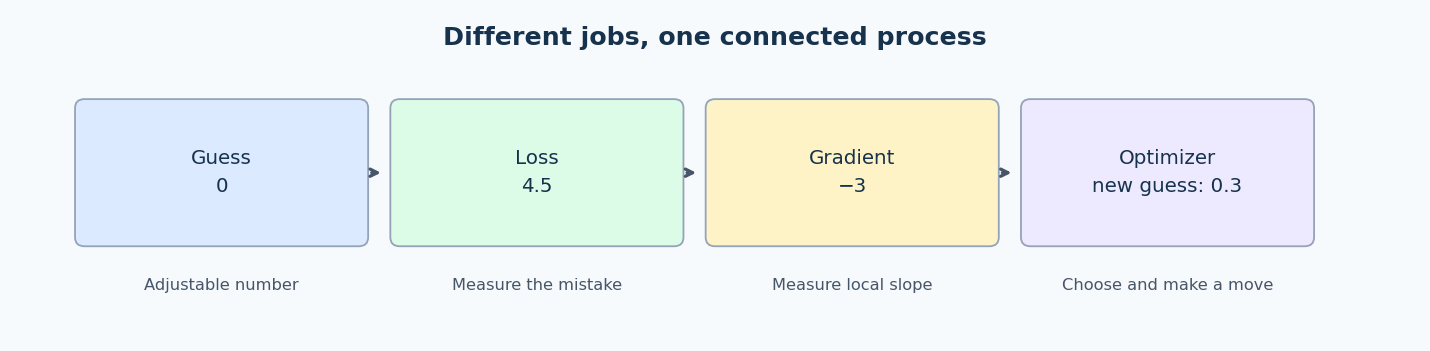

The optimizer does not decide what “good” means. We supply a **loss function**, a rule that scores mistakes. We also calculate **gradients**, which describe how that score responds to small parameter changes. The optimizer turns that information into a move.

The [code companion](08_Optimizers.ipynb) follows this dial, adds memory, and compares paths with two dials. These are exact toy calculations, not a trained predictor or a contest to find a universally best optimizer.

## Start with the problem this lesson solves

A gradient tells us a local direction, but a network still needs a rule for actually moving its parameters. The optimizer chooses that move. Too small a learning rate may make progress slow; too large a rate may overshoot and increase loss.

We isolate one parameter so the update is visible. Think of a neuron with constant input one, no bias, and prediction $w$. Its target is three. The loss is $L(w)=	frac12(w-3)^2$. The same update principles apply to the many weights of an ANN.

## Compare complete parameter updates on one tiny problem

Start at $w=0$. Prediction is zero, error is $0-3=-3$, loss is $\tfrac12(-3)^2=4.5$, and gradient is $g=w-3=-3$.

**Plain SGD:** with rate $\eta=0.1$, use $w'=w-\eta g=0-0.1(-3)=0.3$. New loss is $\tfrac12(0.3-3)^2=3.645$. At the next step the gradient is recomputed: $0.3-3=-2.7$. The next weight is $0.3-0.1(-2.7)=0.57$, with loss $\tfrac12(-2.43)^2=2.95245$. Reusing the first gradient forever would not be ordinary gradient descent.

**Why the rate matters:** from the original $w=0$, a rate of one gives $w'=3$, reaching the minimum of this particular quadratic in one step. A rate of three gives $w'=9$ and loss $\tfrac12(9-3)^2=18$, worse than $4.5$. The negative-gradient direction was correct locally; the move was too large.

**Momentum:** use buffer $m_t=0.9m_{t-1}+g_t$, start $m_0=0$, and update $w_t=w_{t-1}-0.1m_t$. First $m_1=-3$ and $w_1=0.3$. Next $g_2=-2.7$, so $m_2=0.9(-3)-2.7=-5.4$ and $w_2=0.3-0.1(-5.4)=0.84$. The buffer carries some earlier direction into the new step. This can accelerate consistent progress but can also overshoot.

**Adam's first step:** restart at zero with gradient $-3$, first-moment factor $0.9$, second-moment factor $0.999$, and zero initial records:

$$m_1=0.9(0)+0.1(-3)=-0.3,$$
$$v_1=0.999(0)+0.001(-3)^2=0.009.$$

Correct the zero-start bias: $\hat m_1=-0.3/(1-0.9)=-3$ and $\hat v_1=0.009/(1-0.999)=9$. At rate $0.1$,

$$w_1=0-0.1\frac{-3}{\sqrt9+10^{-8}}\approx0.1.$$

The new loss is approximately $\tfrac12(0.1-3)^2=4.205$. Here Adam's first move is smaller than SGD's. This single step does not rank optimizers generally: the methods manage direction and scale differently over a whole training trajectory.

## Why an ANN needs this separate step

Backpropagation computes the current gradient. SGD uses it directly; momentum keeps a direction buffer; Adam keeps direction and squared-gradient records for each parameter. These records are additional optimizer state, not additional neurons.

The learning rate still matters with Adam. Weight decay is another choice that discourages large parameter values; it is distinct from merely following the data loss. Validation performance and stable learning curves are more useful than assuming one optimizer is always best. At inference, only the learned model computation is needed; optimizer state is needed to resume the same training process.

## Draw the mistake as a bowl

Call the dial value $w$. Its error is $w-3$. We score it with half the squared error:

$$L(w)=\frac{(w-3)^2}{2}.$$

$L$ names the loss. Squaring multiplies the error by itself, so being too low or too high both produce a positive penalty. Dividing by two simplifies the slope arithmetic without moving the best setting.

| Dial value $w$ | Error $w-3$ | Square the error | Loss |
| --- | --- | --- | --- |
| 0 | -3 | 9 | 4.5 |
| 2 | -1 | 1 | 0.5 |
| 3 | 0 | 0 | 0 |
| 4 | 1 | 1 | 0.5 |

If we draw loss vertically against the dial position horizontally, these points lie on a bowl. The bottom is at three. Moving toward it reduces the score.

A **gradient** for one parameter is its local slope, also called a derivative. Here the slope is $g=w-3$: squaring gives a factor of two, which cancels the division by two. At zero, the gradient is minus three.

| Position | Gradient sign | What a tiny increase in $w$ does |
| --- | --- | --- |
| Below three | Negative | Lowers the loss |
| At three | Zero | No first-order change; here we are at the minimum |
| Above three | Positive | Raises the loss |

With many parameters, the gradient has one entry per adjustable number. **Backpropagation** calculates those entries by following the model's operations backward. Calculating a gradient does not itself turn a dial.

## Turn the slope into a small move

The simplest rule moves against the gradient:

$$w_{\mathrm{new}}=w_{\mathrm{old}}-\eta g.$$

The positive number $\eta$, pronounced “eta,” is the **learning rate**. It scales the movement. With $\eta=0.1$, starting at zero gives:

$$w_{\mathrm{new}}=0-0.1(-3)=0.3.$$

Subtracting a negative number increases the value, which is the helpful direction here. The new loss is $(0.3-3)^2/2=3.645$, down from $4.5$.

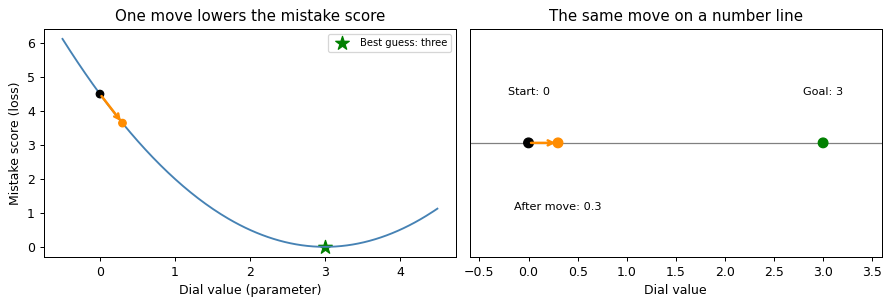

Before another move, calculate a **fresh** gradient at the new position:

| Before the move | Current gradient | Change $-0.1g$ | After the move |
| --- | --- | --- | --- |
| 0 | -3 | +0.3 | 0.3 |
| 0.3 | -2.7 | +0.27 | 0.57 |

The second move is smaller because the slope is less steep closer to the bottom. Repeatedly applying this rule is **gradient descent**.

PyTorch provides the basic rule through `SGD`, short for **stochastic gradient descent**. “Stochastic” means involving randomness: in training, gradients often come from randomly sampled batches of examples rather than the entire dataset. Our bowl uses its exact formula, so these dial movements contain no sampling noise even though we use the same optimizer class.

## See why a bigger step can become a worse step

A gradient describes nearby behavior. A large movement can travel past the region it described.

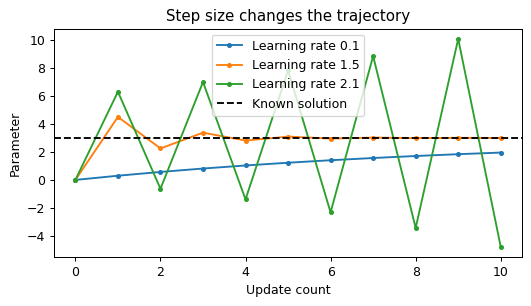

| Learning rate in this bowl | First move from zero | What repeated moves do |
| --- | --- | --- |
| 0.1 | To 0.3 | Approach three gradually |
| 1.5 | To 4.5 | Cross the target, then return closer each time |
| 2.1 | To 6.3 | Cross the target with growing distances |

The dashed line in the picture is the known target. Crossing it is not automatically a failure; what matters here is whether the distance shrinks. Moving farther away over repeated updates is called **divergence**.

We can explain the behavior exactly. Subtract three from both sides of the update:

$$w_{\mathrm{new}}-3=(1-\eta)(w_{\mathrm{old}}-3).$$

Each move multiplies the signed distance by $1-\eta$. With rate $0.1$, the factor is $0.9$, so the distance shrinks without switching sides. With rate $1.5$, the factor is $-0.5$, so the side flips and the distance halves. With rate $2.1$, the factor is $-1.1$, so the distance grows.

For this particular bowl, rates strictly between zero and two converge to the bottom. At two, a nonzero starting error keeps bouncing. These boundaries belong to this formula; a steeper bowl can need a smaller rate. They are not settings to copy blindly into a network.

## Remember earlier pushes with momentum

Imagine pushing a shopping cart. It retains some motion from previous pushes. **Momentum** borrows the idea of memory: an optimizer keeps a **buffer**, a stored summary of earlier gradients.

For the ordinary momentum rule in the companion:

$$B_{\mathrm{new}}=\mu B_{\mathrm{old}}+g,
\qquad w_{\mathrm{new}}=w_{\mathrm{old}}-\eta B_{\mathrm{new}}.$$

$B$ names the buffer, starting at zero. The setting $\mu$ (“mu”) is the fraction of the old buffer retained. With $\mu=0.9$, keep ninety percent of that memory and add the current gradient. The learning rate remains $0.1$.

| Move | Current gradient | New buffer | New dial value |
| --- | --- | --- | --- |
| First | -3 | $0.9(0)-3=-3$ | $0-0.1(-3)=0.3$ |
| Second | -2.7 | $0.9(-3)-2.7=-5.4$ | $0.3-0.1(-5.4)=0.84$ |

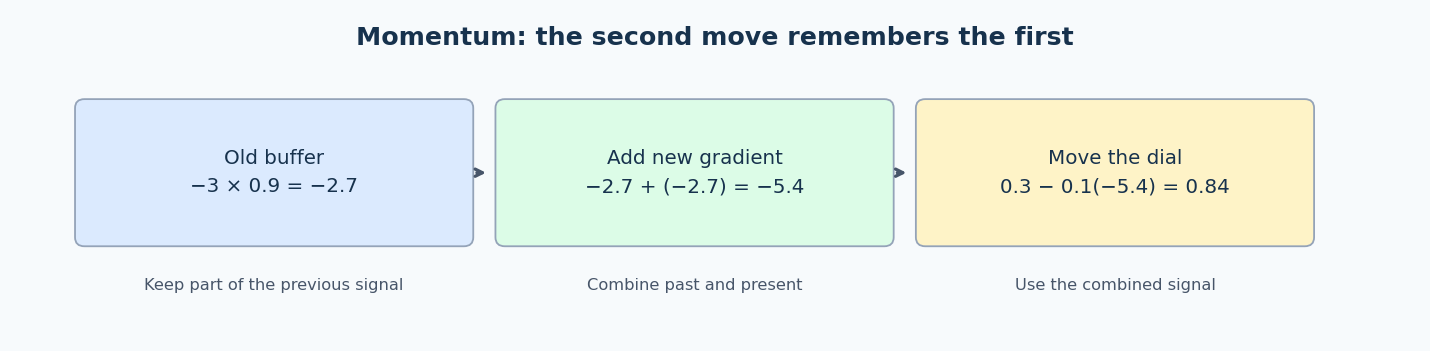

Plain SGD reached $0.57$ after two moves; momentum reaches $0.84$. Consistent directions reinforce one another. Alternating directions can partly cancel in the buffer, which can help reduce some zigzagging.

The cart analogy is only an intuition: this is a numerical rule, not a physical simulation. Memory can also carry a parameter past a useful position. The companion uses ordinary momentum with no dampening or Nesterov modification so its arithmetic matches this exact recipe.

## Give each dial its own record of direction and size

Different parameters can have very different gradient scales. **Adam**, short for adaptive moment estimation, keeps two running records for each parameter and uses them to scale its move.

A **running average** blends old information with a new measurement. It remembers the past while gradually giving old measurements less influence.

| Record | What it averages | What it helps describe |
| --- | --- | --- |
| $m$ | Gradients, with their signs | Recent direction |
| $v$ | Squared gradients | Recent size without positive and negative values canceling |

Adam's records update as follows:

$$m_{\mathrm{new}}=\beta_1m_{\mathrm{old}}+(1-\beta_1)g,$$
$$v_{\mathrm{new}}=\beta_2v_{\mathrm{old}}+(1-\beta_2)g^2.$$

The settings $\beta_1$ and $\beta_2$, read “beta one” and “beta two,” are the fractions of old information retained. Their complements, $1-\beta$, are the fractions given to the new measurement. The companion uses $0.9$ and $0.999$.

These are separate records for each parameter coordinate, not one shared number for the whole network. The squared-size record is nonnegative. Its square root will let us compare size on the same scale as the original gradient.

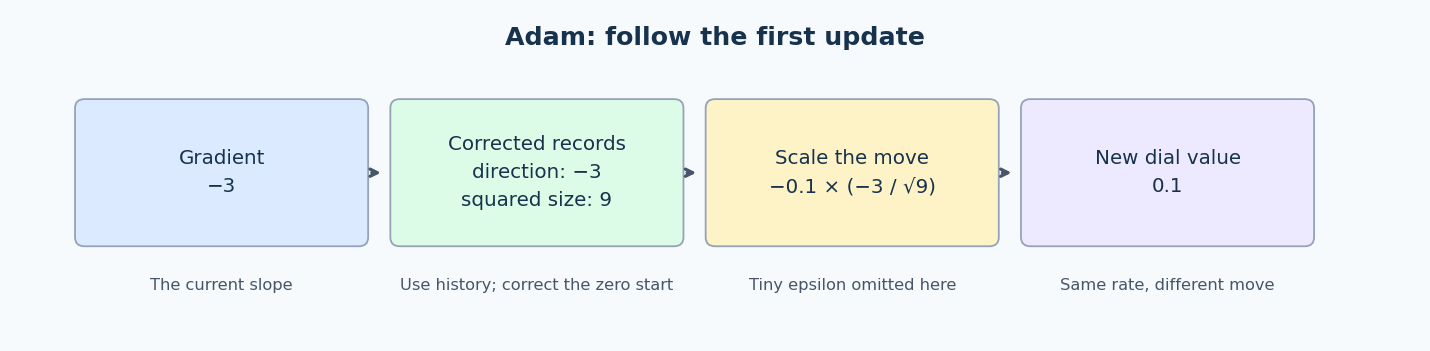

## Follow Adam's first move without skipping the arithmetic

Both records start at zero. For the first gradient $g=-3$, the records become small partly because much of each running average still comes from that empty start.

| Record | Blend old and new | Correct the initial zero |
| --- | --- | --- |
| $m$ | $0.9(0)+0.1(-3)=-0.3$ | $-0.3/(1-0.9)=-3$ |
| $v$ | $0.999(0)+0.001(9)=0.009$ | $0.009/(1-0.999)=9$ |

This adjustment is **bias correction**. Here “bias” refers to the initial pull of a running average toward zero, not the bias parameter added inside a neuron.

After update count $t$, divide $m$ by $1-\beta_1^t$ and $v$ by $1-\beta_2^t$. A power such as $\beta^t$ means multiplying $\beta$ by itself $t$ times. Denote the corrected values by $\hat m$ and $\hat v$, where the hats mark the correction.

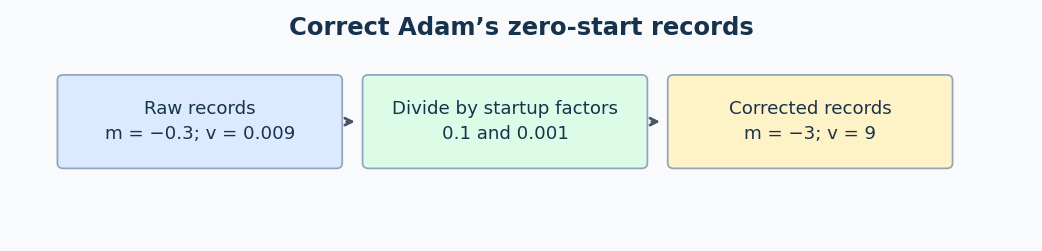

Adam then uses:

$$w_{\mathrm{new}}=w_{\mathrm{old}}-\eta\frac{\hat m}{\sqrt{\hat v}+\epsilon}.$$

The square root restores the squared record to the original gradient scale. The tiny positive $\epsilon$ (“epsilon”) prevents division by zero; the companion uses $10^{-8}$, or $0.00000001$.

For our first move, the ratio is approximately $-3/\sqrt9=-1$. With learning rate $0.1$, the dial moves from zero to approximately $0.1$.

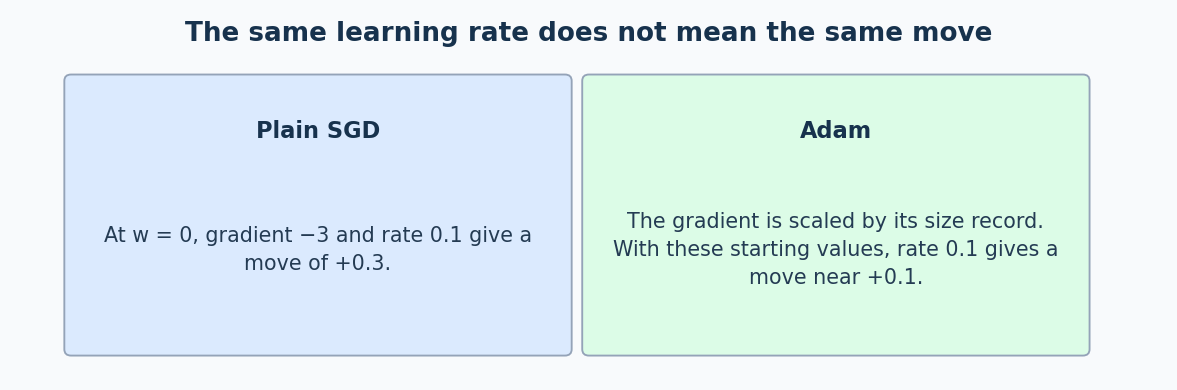

Adam does not always move a fixed distance or exactly one learning rate. Both records evolve, and their ratio changes. Its scaling can be useful, but a suitable learning rate still matters.

## Watch two dials move through a narrow valley

Call two parameters $a$ and $b$, and give them the loss:

$$L(a,b)=\frac{a^2}{2}+10b^2.$$

The minimum is at $(0,0)$. The gradient is $(a,20b)$: differentiating the squared terms doubles their factors. Changes in $b$ are penalized more steeply than equally sized changes in $a$.

At the starting point $(4,1)$, the gradient is $(4,20)$. Plain SGD with rate $0.05$ moves to $(4-0.05\times4,\ 1-0.05\times20)=(3.8,0)$. The two coordinates can make very different moves in one update.

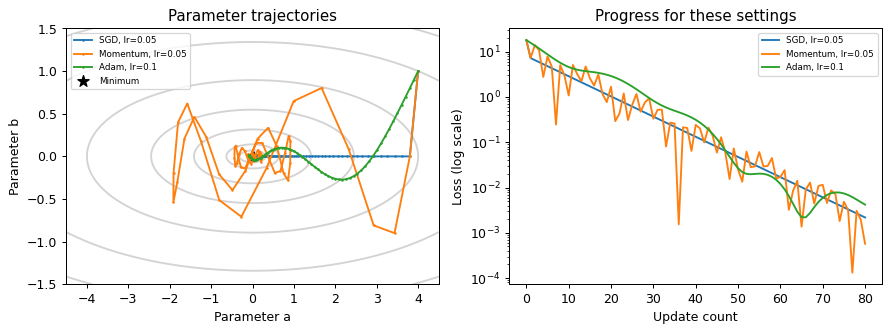

On the left, **contour lines** join positions with equal loss, like equal-height lines on a map. A colored path connects the parameter settings visited by one optimizer. On the right, each curve shows loss over updates. The vertical axis is logarithmic: equal vertical distances represent equal multiplication factors, making small losses easier to see.

The companion gives each optimizer fresh parameters and independent memory, starts them at the same point, and makes eighty updates. SGD and momentum use rate $0.05$; Adam uses $0.1$, as labeled in the plot.

This is a demonstration of behavior under those settings. It does not establish a winner: changing the rates, update budget, or loss surface can change the comparison. Real networks also have more complicated surfaces and noisy batch gradients.

## Add a separate pull toward smaller parameter values

Sometimes we want to discourage very large weights as well as fit the examples. **Weight decay** adds a pull toward zero. That is a modeling choice, not a guarantee of better predictions.

**AdamW** separates this shrinkage from Adam's gradient records. With parameter $w$, learning rate $\eta$, and decay strength $\lambda$ (“lambda”), its decay contribution is $-\eta\lambda w$.

If the data-loss gradient is explicitly zero and there is no earlier optimizer history, only the shrinkage remains. For $w=2$, $\eta=0.1$, and $\lambda=0.1$:

$$w_{\mathrm{new}}=2(1-0.1\times0.1)=1.98.$$

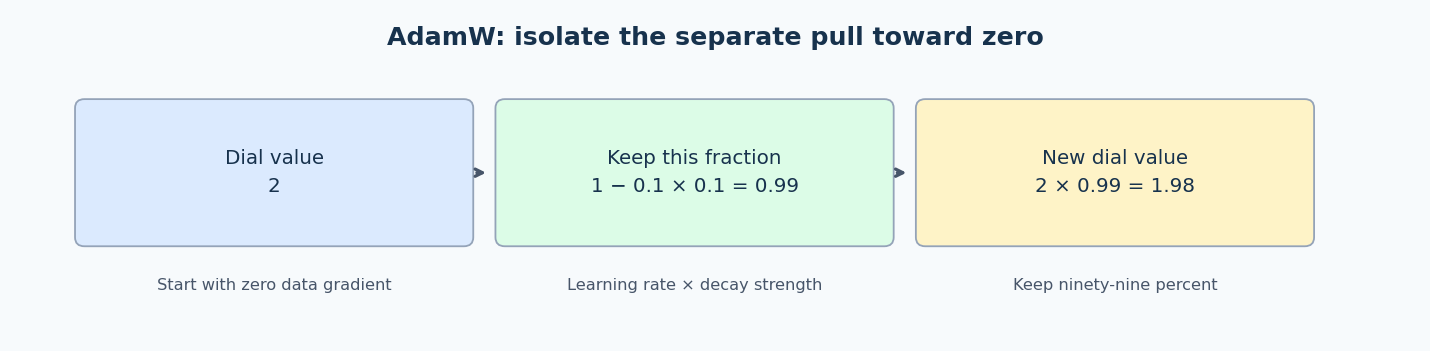

A different approach adds an **L2 penalty**, $\lambda w^2/2$, to the loss. Its gradient is $\lambda w$. This gradient joins the data-loss gradient before the optimizer processes it.

| Method in the companion | What happens to the extra pull? | First decay-only result |
| --- | --- | --- |
| Coupled Adam | The penalty gradient enters Adam's running records and scaling | About 1.9 |
| AdamW | Shrinkage is applied separately from those records | 1.98 |

For the coupled Adam case, the first gradient is $0.1\times2=0.2$. After correction, the adaptive ratio is approximately $0.2/\sqrt{0.04}=1$, producing a move of about $0.1$.

With plain SGD without momentum, adding the L2 gradient gives the same update as separate multiplicative shrinkage. Adam's adaptive processing generally makes the two approaches different, as the table shows. A missing gradient (`None`) can cause a parameter to be skipped, so the companion supplies an explicit zero tensor to isolate decay.

## Keep current gradients separate from optimizer memory

We now have two kinds of stored information. Confusing them can silently change an update.

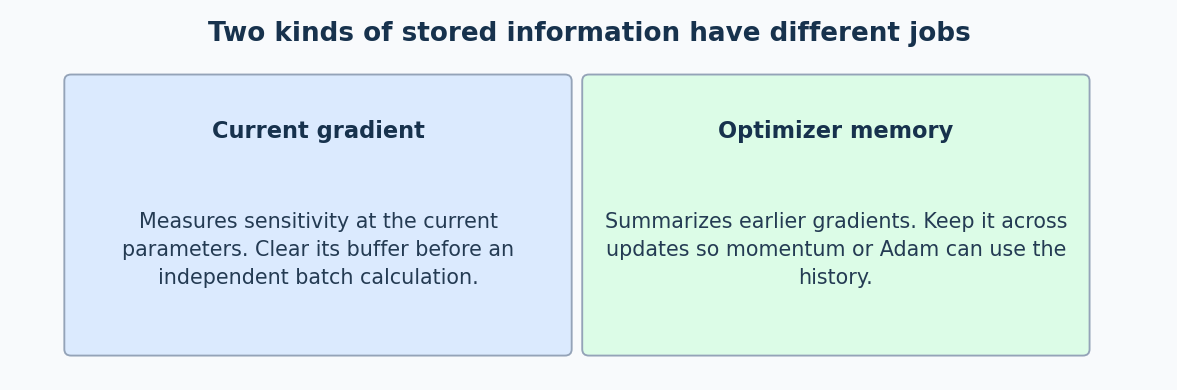

| Operation | What it does | What it preserves |
| --- | --- | --- |
| `optimizer.zero_grad(...)` | Clears old gradient contributions | Parameters and optimizer history |
| `loss.backward()` | Calculates and accumulates current derivatives | Parameter values |
| `optimizer.step()` | Applies the chosen parameter update | History needed for later updates |

Create momentum or Adam once for a continuing run. Recreating the optimizer each batch throws away its records, changing the process even if the weights remain the same. Saving a model's weights is enough to use it for predictions, but faithfully resuming its updates also needs the optimizer state and other run state.

The companion checks the manual arithmetic against PyTorch's stored records. This verifies how the rules move our dials; it does not establish predictive performance on real data.

| Rule | Main information used |
| --- | --- |
| Plain SGD | The current gradient |
| Momentum | Current gradient plus a remembered buffer |
| Adam | Smoothed direction and squared-size records |
| AdamW | Adam's adaptive move plus separate shrinkage |

An optimizer can move the parameters of the calculation we give it. It cannot correct mislabeled examples, choose the right objective for us, or ensure that a lower training loss means useful predictions on new examples.

## Compare update memories and learning-rate plans

Full-batch descent averages every example for one update; single-example SGD updates after each example; mini-batch descent averages a subset. At fixed parameters, the mean of per-example gradients equals the full-batch gradient, but sequential updates evaluate later gradients at changed parameters.

Nesterov momentum evaluates a correction at a momentum-informed point. AdaGrad accumulates squared gradients and can shrink coordinate steps over time. RMSProp exponentially forgets old squared gradients. Nadam combines Adam-style moments with a Nesterov-style direction. These are different state conventions, so compare implementations by documented updates rather than mixing equations.

A schedule changes the shared learning rate over time: step decay drops it at fixed intervals, exponential decay multiplies it by a constant fraction each count, and cosine annealing smoothly lowers it toward a minimum over a chosen horizon. Define whether the count is batches, updates, or epochs.